# Word frequencies


The most basic questions that we can answer using a corpus start with frequency, or how often something occurs in it, and most of the more advanced questions build from there. This notebook works through some of the basics using polars:

1. **Absolute frequency** — counting types with `group_by`.
2. **Relative frequency** — normalizing counts so corpora of different sizes can be compared.
3. **Zipf's law** — the rank/frequency distribution that every corpus turns out to have.
4. **Variation between texts** — per-file rates, their distributions, and how they covary.
5. **Ratios** — normalizing against a choice set instead of against corpus size.

Nearly all of this is plain Polars -- a corpus is just data, after all! -- and we'll use Seaborn and matplotlib to handle the plots.


In [1]:
import polars as pl
import polars_corpus as plc
import polars.selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_rows(20)
pl.Config.set_float_precision(3)
pl.Config.set_thousands_separator(",")

polars.config.Config

## The corpus

Our corpus data is represented as a DataFrame with one row per token, in corpus order. Annotations and metadata are stored in extra columns for each row.  

These examples use [AMALGUM](https://gucorpling.org/gum/amalgum.html), a freely redistributable,  automatically annotated corpus of English in seven genres (academic writing, biographies, fiction,
interviews, news, travel guides, and how-to guides). The corpus consists of 3.85 million tokens in 4,682 texts.

The columns:

| column         | contents |
|----------------| --- |
| `token`        | the word form as it appears in the text |
| `pos`          | part-of-speech tag (Penn Treebank tagset) |
| `lemma`        | dictionary form of the token |
| `sentence_tag` | `B` on the first token of a sentence, `I` elsewhere |
| `file_id`      | the document the token belongs to |
| `text_type`    | the document's genre |


In [2]:
amalgum = pl.read_parquet("../../data/amalgum.parquet")
amalgum.head(10)

token,pos,lemma,sentence_tag,file_id,text_type
str,str,str,str,str,str
"""1.""","""LS""","""1.""","""B""","""AMALGUM_academic_acrylamide""","""academic"""
"""Introduction""","""NN""","""introduction""","""I""","""AMALGUM_academic_acrylamide""","""academic"""
"""Acrylamide""","""NNP""","""Acrylamide""","""B""","""AMALGUM_academic_acrylamide""","""academic"""
""",""",""",""",""",""","""I""","""AMALGUM_academic_acrylamide""","""academic"""
"""a""","""DT""","""a""","""I""","""AMALGUM_academic_acrylamide""","""academic"""
"""thermal""","""JJ""","""thermal""","""I""","""AMALGUM_academic_acrylamide""","""academic"""
"""processing""","""NN""","""processing""","""I""","""AMALGUM_academic_acrylamide""","""academic"""
"""contaminant""","""NN""","""contaminant""","""I""","""AMALGUM_academic_acrylamide""","""academic"""
"""with""","""IN""","""with""","""I""","""AMALGUM_academic_acrylamide""","""academic"""


Tokens and documents are roughly divided evenly across the seven text types:

In [3]:
(
    amalgum.group_by("text_type").agg(
        pl.col("file_id").n_unique().alias("n_files"),
        pl.col("token").len().alias("n_tokens"),
    )
)

text_type,n_files,n_tokens
str,u32,u32
"""bio""",598,"498,310"
"""whow""",630,"513,967"
"""voyage""",600,"660,773"
"""academic""",746,"562,642"
"""news""",808,"590,830"
"""interview""",822,"500,971"
"""fiction""",478,"522,936"


## Token frequency

### Absolute frequency

With one row per token, a frequency list is a count of repeated values. `group_by("token")`
gathers the rows that share a form, `pl.len()` counts the rows in each group, and sorting on that
count descending puts the most frequent first.

Each row of the corpus is a **token** (an occurrence of a word), while
each row of the frequency list is a **type** (a distinct form). AMALGUM has 3,850,429 tokens and
143,502 types.


In [4]:
(
    amalgum.group_by("token")
    .agg(pl.len().alias("count"))
    .sort(by="count", descending=True)
    .head(20)
)

token,count
str,u32
""",""","192,424"
"""the""","182,501"
""".""","165,368"
"""of""","100,394"
"""and""","95,116"
"""to""","84,596"
"""a""","67,458"
"""in""","63,088"
"""is""","35,666"


The twenty most frequent types are function words and punctuation marks. If we're counting "words", then we probably want to exclude the punctuation marks. Also notice that *the* and *The* appear as two distinct types. By default, upper and lower case letters count as distinct characters.

Typically we will want to **normalize** texts before analyzing them. That is, we will smooth out details that aren't relevant to the questions we're asking. In this case, `plc.is_letters` keeps the types made of letters and drops the rest (punctuation, numbers, emojis), while leaving the apostrophes and hyphens inside words like *don't* and *co-op* alone, and `str.to_lowercase` folds *The* in with *the*. What is left is 3,242,241 tokens of 107,893 types.

In [5]:
abs_freq = (
    amalgum.filter(plc.is_letters("token"))
    .with_columns(pl.col("token").str.to_lowercase())
    .group_by("token")
    .agg(pl.len().alias("count"))
    .sort(by="count", descending=True)
)
abs_freq.head(20)

token,count
str,u32
"""the""","204,055"
"""of""","100,824"
"""and""","97,081"
"""to""","85,730"
"""a""","71,425"
"""in""","69,642"
"""is""","36,100"
"""that""","30,152"
"""for""","29,847"


### Relative frequency


Raw counts are only meaningful within one corpus. To compare a word's frequency here with its
frequency in a corpus of a different size, the count has to be expressed as a rate:

$$\text{rate} = \frac{\text{count}}{\text{corpus size}} \times \text{basis}$$

`plc.proportion` divides each count by the total of the column, giving the proportion rather than the count, and multiplying by a basis turns a very small decimal into a more easily readable number. The choice of basis is a matter of presentation: per 10,000 words works well for common words in short texts. Relative frequencies in larger corpora are often reported per million words. Here we scale by 10,000, so a value of 629 means we can expect to find on average about six *the*s in every hundred words.


In [6]:
rel_freq = abs_freq.select("token", (plc.proportion("count") * 10_000).alias("rate"))
rel_freq.head(10)

token,rate
str,f64
"""the""",629.364
"""of""",310.970
"""and""",299.426
"""to""",264.416
"""a""",220.295
"""in""",214.796
"""is""",111.343
"""that""",92.997
"""for""",92.057


### Zipf's law

The most frequent types are very frequent. Normalizing left 107,893 distinct types:

In [7]:
len(rel_freq)

107893

but the top ten types account for 23% of the tokens:

In [8]:
rel_freq.head(10).select("rate").sum() / 100

rate
f64
23.208


and almost half occur exactly once:

In [9]:
len(abs_freq.filter(pl.col("count") == 1))

50663


Frequency lists from natural language all have the same shape. If the types are ranked from most
to least frequent, frequency falls off roughly as a power of the rank,

$$f(r) \approx \frac{C}{r^{a}}$$

with $a$ near 1: the second-ranked word occurs about half as often as the first, the tenth about
a tenth as often, and so on.

`abs_freq` folded case already, so *The* and *the* count as one type, and
`with_row_index("rank", offset=1)` numbers the rows of the already-sorted table, giving rank 1 to
the most frequent type. On linear axes the top 500 types drop away almost immediately: a few
dozen very common words, then a tail that looks flat (but actually isn't).


<Axes: xlabel='rank', ylabel='count'>

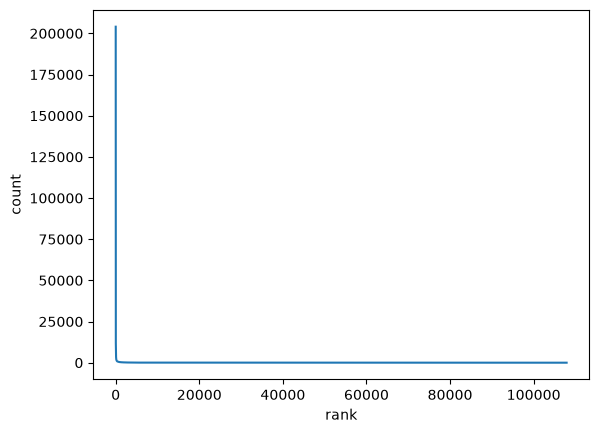

In [10]:
zipf = abs_freq.with_row_index("rank", offset=1)
sns.lineplot(x="rank", y="count", data=zipf)

<Axes: xlabel='rank', ylabel='count'>

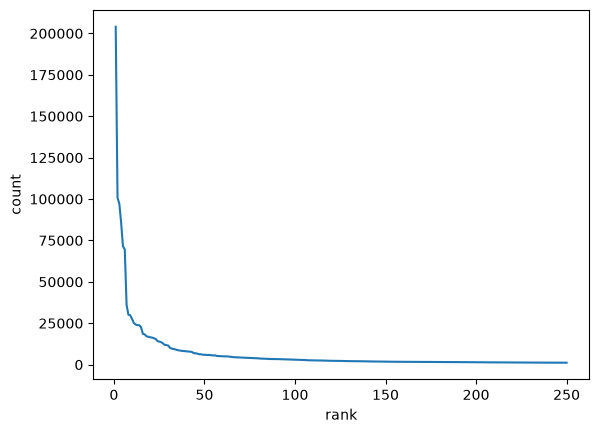

In [11]:
sns.lineplot(x="rank", y="count", data=zipf.head(250))

The same curve on log–log axes is close to a straight line over several orders of magnitude. This is what and inverse power law looks like: a constant proportional drop in frequency for a constant
proportional step in rank.

The staircase at the right-hand end is due to the fact the counts are whole numbers. A word can occur three or four times but not 3.2 times. The final, longest step is the words that occur exactly once, called *hapax legomena*.


<Axes: xlabel='rank', ylabel='count'>

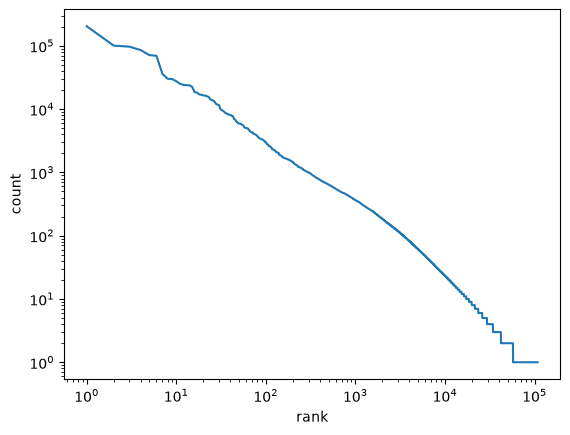

In [12]:
plt.loglog()
sns.lineplot(x="rank", y="count", data=zipf)

## Variation between texts

A corpus-wide rate is an average, and averages hide variation between parts of the corpus. The same word can be frequent because every text uses it a little or because a few texts use it a lot. To balance these effects, we can compute the rate separately for each file. 

The pipeline below restricts the corpus to the 822 interview files, folds case, and then groups
by `file_id`, aggregating four things per file: its length `n`, and the counts of *the*, *I* and
*you*. Comparisons like `pl.col("token") == "the"` produce a boolean column, and `.sum()` on a
boolean counts the `True` values. This is the standard Polars idiom for "count rows matching a
condition" inside an aggregation.

The `select` then normalizes all the counts in one step: `cs.numeric().exclude("n")` picks every numeric column except the file length, divides each by `n`, and scales to a rate per 10,000 words. Using a selector rather than naming the three words keeps the expression the same length however many words are tracked.

(see Brezina (2018), *Statistics in Corpus Linguistics*, p. 26 for more about this example.)


In [13]:
the = (
    amalgum.filter(pl.col("text_type") == "interview")
    .with_columns(pl.col("token").str.to_lowercase())
    .group_by("file_id")
    .agg(
        (
            pl.col("token").len().alias("n"),
            (pl.col("token") == "the").sum().alias("the"),
            (pl.col("token") == "i").sum().alias("i"),
            (pl.col("token") == "you").sum().alias("you"),
        )
    )
    .select("file_id", (cs.numeric().exclude("n") / pl.col("n") * 10_000))
)

the.head(10)

file_id,the,i,you
str,f64,f64,f64
"""AMALGUM_interview_teachings""",290.698,213.178,96.899
"""AMALGUM_interview_nbgi""",515.464,51.546,51.546
"""AMALGUM_interview_ambassador""",323.194,114.068,57.034
"""AMALGUM_interview_francisco""",592.734,38.241,0.000
"""AMALGUM_interview_nomination""",572.917,277.778,34.722
"""AMALGUM_interview_commissioner""",587.121,94.697,56.818
"""AMALGUM_interview_shiflett""",520.446,99.133,61.958
"""AMALGUM_interview_marion""",287.648,406.091,152.284
"""AMALGUM_interview_principality""",510.204,0.000,20.408


### How are the per-file rates distributed?

With rates computed by file,  we can now look at the distribution of values rather than the average. The two histograms are shaped quite differently:

- *the* is roughly symmetric around 435 per 10,000, but ranges from under 100 to over 1,000. 
- *I* is strongly right-skewed, with a mode near zero and a long tail. Some interviews are
  first-person narratives, but many are not.

For a distribution like the second one the mean is not a good summary, which is worth remembering
whenever a corpus is reported as a single relative frequency.


<Axes: xlabel='the', ylabel='Count'>

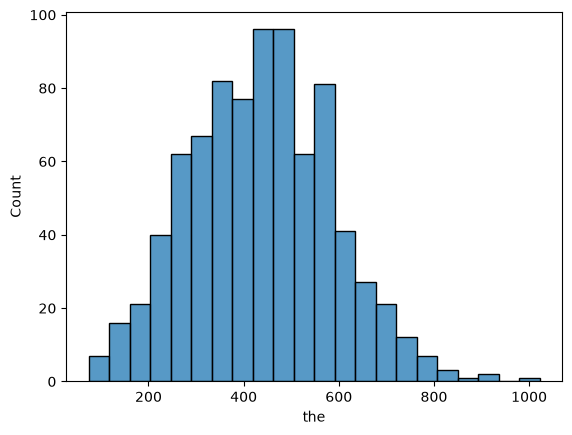

In [14]:
sns.histplot(data=the, x="the")

<Axes: xlabel='i', ylabel='Count'>

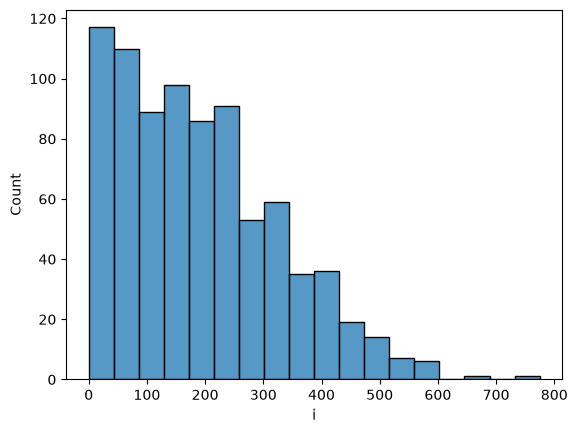

In [15]:
sns.histplot(data=the, x="i")

### Do the rates move together?

Each point in the figure below is one interview file, plotted by its rate of *the* and its rate of *I*. The red line is a LOWESS smoother (`lowess=True`).

The trend is clearly negative: files that use *the* heavily use *I* sparingly, and vice versa.


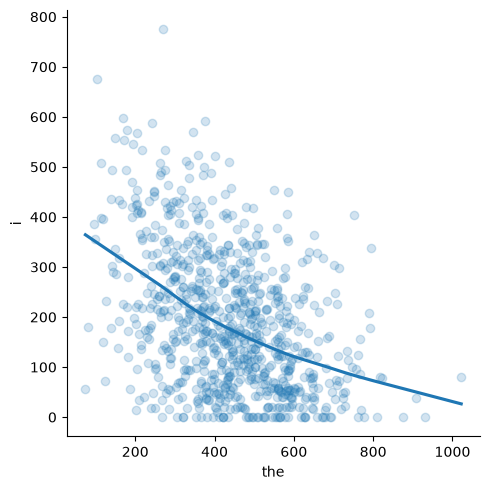

In [16]:
sns.lmplot(the, x="the", y="i", lowess=True, scatter_kws=dict(alpha=0.2))

A pair plot shows all three words at once: histograms on the diagonal, a scatter with a smoother
for each pair below it. `corner=True` drops the redundant upper triangle. Seaborn is built for pandas dataframes and has inconsistent support for polars. It accepted the 
Polars dataframes directly for the plots above, but `pairplot` still requires explicit conversion.

*I* and *you* rise together and both fall as *the* rises. The three rates are not three
independent variables. Rather, they are three aspects of a single dimension of variation, the contrast between involved, interactive language and informational language (Biber 1988).


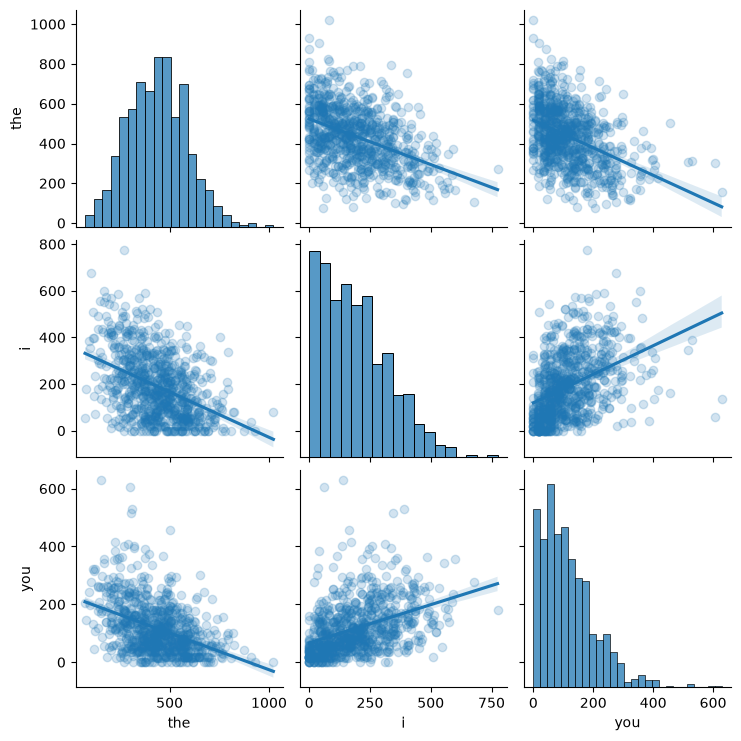

In [17]:
sns.pairplot(the.to_pandas(), kind="reg", plot_kws=dict(scatter_kws=dict(alpha=0.2)))

# fig = px.scatter_matrix(the, dimensions=["the", "i", "you"], opacity=0.3)

# fig.update_traces(
#    diagonal_visible=False,
#    showupperhalf=False,
# )

## Ratios instead of rates

Dividing by the size of the text is not the only way to make counts comparable. When two words
compete for the same slot, the more informative denominator is the choice itself: given that a
writer reached for an intensifier, how often did they pick *really* over *very*?

$$\text{ratio} = \frac{f(\textit{really})}{f(\textit{really}) + f(\textit{very})}$$

This measure needs no normalization — it is unaffected by text length, and unaffected by how
much a text intensifies at all. The pipeline below counts both words per file, forms the ratio,
then averages the ratios within each genre. Two details worth noting:

- `pl.col('text_type').first()` carries the genre label through the `group_by`. The value is
  constant within a file, so any one row will do.
- `.drop_nans()` discards files containing neither word, where the ratio is $0/0$.

Averaging the per-file ratios (rather than pooling all the counts and dividing once) gives every
text an equal vote, so a handful of long files cannot dominate the genre.

The ratios line up as a gradient running from the most edited, most informational genre to the
most speech-like one: *really* takes 3% of the *really*/*very* choices in academic writing but
43% of them in interviews. That is a fact about register, not about how much intensifying each
genre does.



In [18]:
ratio = (
    amalgum.with_columns(pl.col("token").str.to_lowercase())
    .group_by("file_id")
    .agg(
        pl.col("text_type").first(),
        (pl.col("token") == "really").sum().alias("really"),
        (pl.col("token") == "very").sum().alias("very"),
    )
    .with_columns(ratio=pl.col("really") / (pl.col("really") + pl.col("very")))
    .drop_nans()
    .group_by("text_type")
    .agg(pl.col("ratio").mean())
    .sort(by="ratio")
)
ratio

text_type,ratio
str,f64
"""academic""",0.031
"""voyage""",0.120
"""bio""",0.124
"""fiction""",0.170
"""news""",0.206
"""whow""",0.294
"""interview""",0.429


<Axes: xlabel='text_type', ylabel='ratio'>

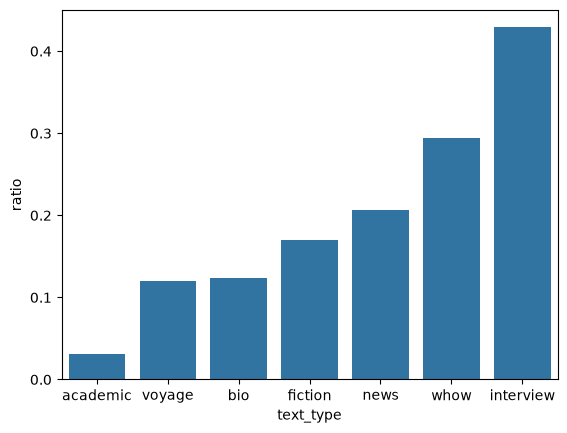

In [19]:
sns.barplot(data=ratio, x="text_type", y="ratio")